# Options Implied Volatility Surface
Fetches live options data for SPY, computes implied volatility via Black-Scholes, and plots the vol surface.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.interpolate import griddata

from src.fetch import get_options_chain, get_risk_free_rate
from src.iv import compute_mid, filter_options, compute_iv
from src.surface import select_otm

TICKER = "SPY"

## 1. Fetch Data

In [13]:
spot, options = get_options_chain(TICKER)
rfr = get_risk_free_rate()

print(f"Ticker : {TICKER}")
print(f"Spot   : ${spot:.2f}")
print(f"RFR    : {rfr:.2%}")
print(f"Raw options: {len(options)}")

Ticker : SPY
Spot   : $656.14
RFR    : 3.62%
Raw options: 8963


## 2. Filter & Compute IV

In [14]:
options = compute_mid(options)
options = filter_options(options, spot)
print(f"After liquidity filter: {len(options)}")

options = compute_iv(options, spot, rfr)
print(f"After IV computation  : {len(options)}")

options.head(10)

After liquidity filter: 6376
After IV computation  : 6195


,expiry,tte,strike,flag,bid,ask,volume,openInterest,mid,iv
0,2026-03-26,0.00274,585.0,c,70.58,73.36,2.0,1,71.970,1.293076
1,2026-03-26,0.00274,595.0,c,60.57,63.24,2.0,20,61.905,1.115701
2,2026-03-26,0.00274,600.0,c,55.59,57.28,2.0,19,56.435,0.853697
3,2026-03-26,0.00274,603.0,c,52.66,54.47,1.0,5,53.565,0.874804
4,2026-03-26,0.00274,610.0,c,45.79,48.22,4.0,4,47.005,0.906491
5,2026-03-26,0.00274,612.0,c,43.69,46.30,8.0,2,44.995,0.871878
6,2026-03-26,0.00274,614.0,c,41.65,43.36,2.0,2,42.505,0.693652
7,2026-03-26,0.00274,615.0,c,40.71,43.31,4.0,4,42.010,0.826989
8,2026-03-26,0.00274,619.0,c,36.71,39.26,2.0,2,37.985,0.756357
9,2026-03-26,0.00274,620.0,c,35.74,37.46,1.0,41,36.600,0.640720


## 3. Prepare OTM Surface Data

In [15]:
otm = select_otm(options, spot)
print(f"OTM options for surface: {len(otm)}")

x = otm["moneyness"].values   # K/S
y = otm["tte"].values          # time to expiry (years)
z = otm["iv"].values           # implied volatility

xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
Xi, Yi = np.meshgrid(xi, yi)

method = "cubic" if len(x) >= 10 else "linear"
Zi = griddata((x, y), z, (Xi, Yi), method=method)
print(f"Interpolation method: {method}")

OTM options for surface: 3480
Interpolation method: cubic


## 4. Matplotlib — Static 3D Surface + Heatmap

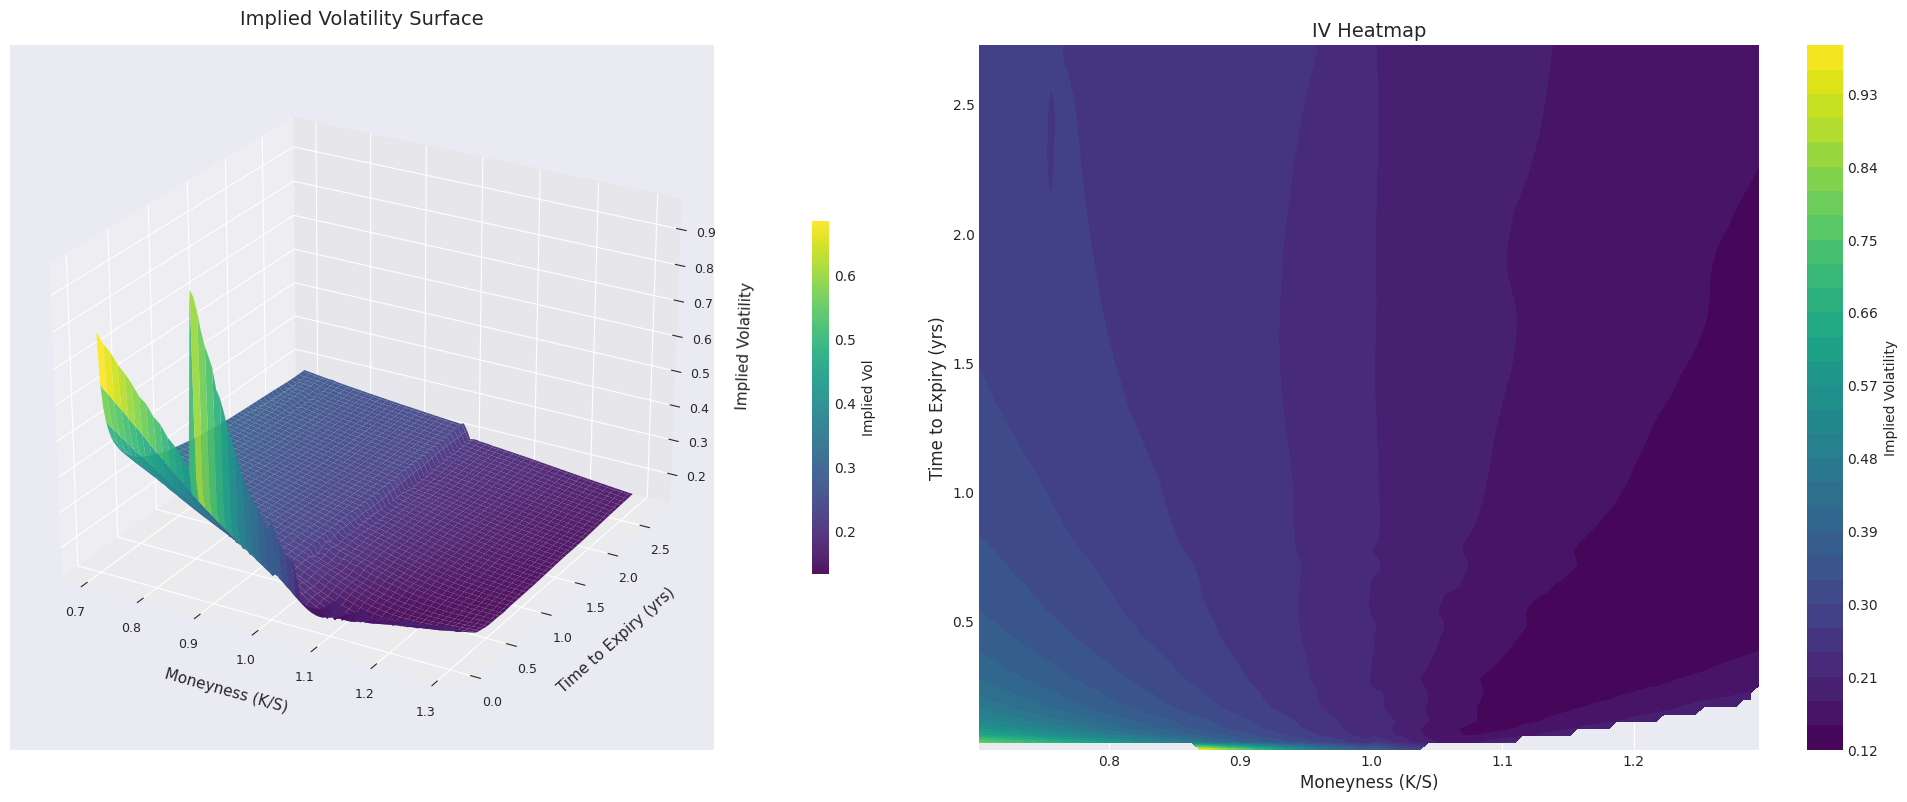

In [16]:
%matplotlib inline

plt.style.use("seaborn-v0_8-darkgrid")
fig = plt.figure(figsize=(20, 8))

# 3D surface
ax1 = fig.add_subplot(121, projection="3d")
surf = ax1.plot_surface(Xi, Yi, Zi, cmap="viridis", alpha=0.92, edgecolor="none")
ax1.view_init(elev=25, azim=-60)
ax1.set_xlabel("Moneyness (K/S)", fontsize=11, labelpad=10)
ax1.set_ylabel("Time to Expiry (yrs)", fontsize=11, labelpad=10)
ax1.set_zlabel("Implied Volatility", fontsize=11, labelpad=10)
ax1.set_title("Implied Volatility Surface", fontsize=14, pad=15)
ax1.tick_params(labelsize=9)
fig.colorbar(surf, ax=ax1, shrink=0.5, pad=0.1, label="Implied Vol")

# Heatmap
ax2 = fig.add_subplot(122)
cf = ax2.contourf(Xi, Yi, Zi, levels=30, cmap="viridis")
cbar = plt.colorbar(cf, ax=ax2, label="Implied Volatility")
cbar.ax.tick_params(labelsize=10)
ax2.set_xlabel("Moneyness (K/S)", fontsize=12)
ax2.set_ylabel("Time to Expiry (yrs)", fontsize=12)
ax2.set_title("IV Heatmap", fontsize=14)
ax2.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("vol_surface.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Plotly — Interactive 3D Surface
Rotate, zoom, and hover over any point to see exact IV levels.

In [17]:
fig = go.Figure()

fig.add_trace(go.Surface(
    x=Xi, y=Yi, z=Zi,
    colorscale="Viridis",
    opacity=0.92,
    colorbar=dict(title="Implied Vol"),
))

fig.update_layout(
    title=f"{TICKER} Implied Volatility Surface",
    scene=dict(
        xaxis_title="Moneyness (K/S)",
        yaxis_title="Time to Expiry (yrs)",
        zaxis_title="Implied Volatility",
    ),
    width=950,
    height=650,
)

fig.show()